In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import pearsonr, gaussian_kde
import networkx as nx

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA



In [3]:
rng = np.random.default_rng(7)
n = 320

stile = rng.choice(["Bianco", "Rosso", "Orange"], size=n, p=[0.46, 0.44, 0.10])

body  = rng.normal(0, 1, n)
fresh = rng.normal(0, 1, n)
e     = rng.normal(0, 1, n)

is_bianco = (stile == "Bianco").astype(float)
is_rosso  = (stile == "Rosso").astype(float)
is_orange = (stile == "Orange").astype(float)

df = pd.DataFrame({
    "stile": stile,
    "alcol": 12 + 1.1*body + 0.15*e + 0.4*is_rosso,
    "acidita": 6 + 1.2*fresh - 0.35*body + 0.25*e,
    "estratto": 20 + 2.2*body + 0.35*e,
    "tannino": (1.1 + 0.5*body + 0.25*e) + (2.0*is_rosso + 0.8*is_orange),
    "zuccheri": 2.2 + 0.9*is_bianco - 0.25*fresh + 0.35*np.maximum(0, -body) + 0.2*e,
    "solfiti": 68 + 10*is_bianco + 6*is_rosso + 2.2*body - 3.0*fresh + 2.0*e,
    "prezzo": 15 + 4.0*body + 1.7*fresh + 2.5*is_orange + 0.9*e,
    "rating": 80 + 2.6*body + 1.2*fresh - 0.6*is_orange + 0.9*e,
    "T_servizio": 10 + 2.0*is_rosso + 1.0*is_orange - 0.6*fresh + 0.2*e,
})

numeric_cols = [c for c in df.columns if c != "stile"]

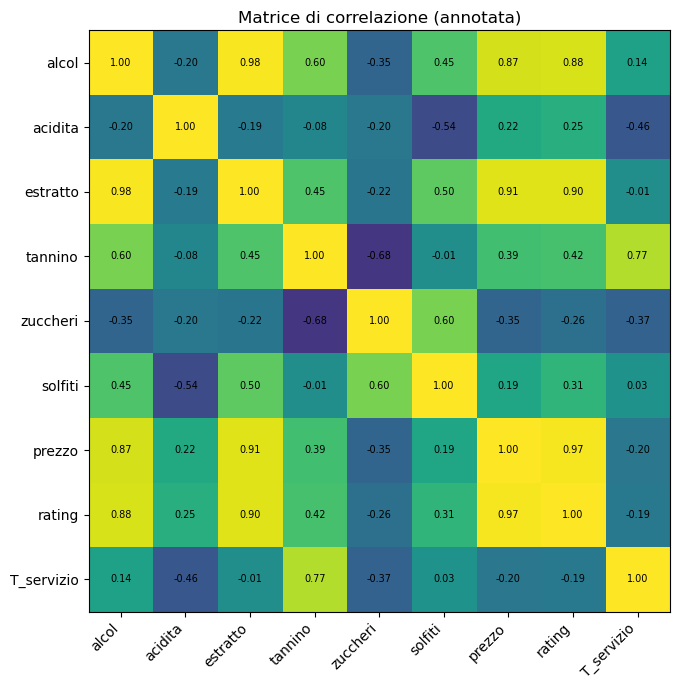

Top 3 correlazioni (per |r|):
- alcol vs estratto: r=0.982
- prezzo vs rating: r=0.970
- estratto vs prezzo: r=0.905


In [4]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))
ax = plt.gca()
ax.imshow(corr.values, vmin=-1, vmax=1)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.index)

ax.set_title("Matrice di correlazione (annotata)")

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)

plt.tight_layout()
plt.show()

# interpretazione “automatica” (top 3 coppie)
pairs = []
cols = corr.columns.tolist()
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        pairs.append((cols[i], cols[j], corr.loc[cols[i], cols[j]]))

top = sorted(pairs, key=lambda t: abs(t[2]), reverse=True)[:3]
print("Top 3 correlazioni (per |r|):")
for a,b,r in top:
    print(f"- {a} vs {b}: r={r:.3f}")

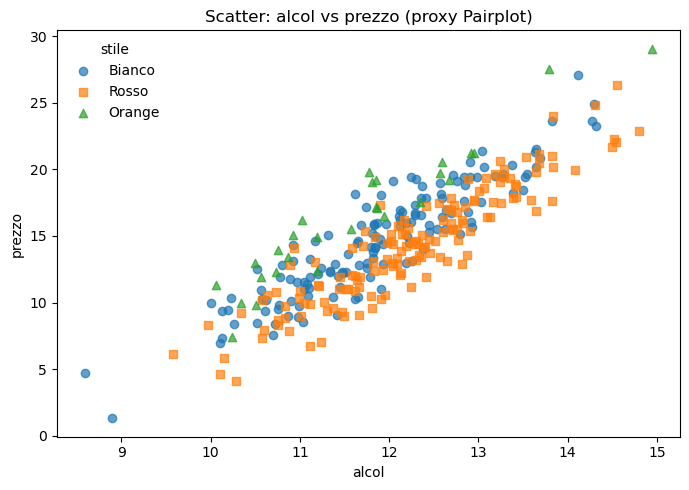

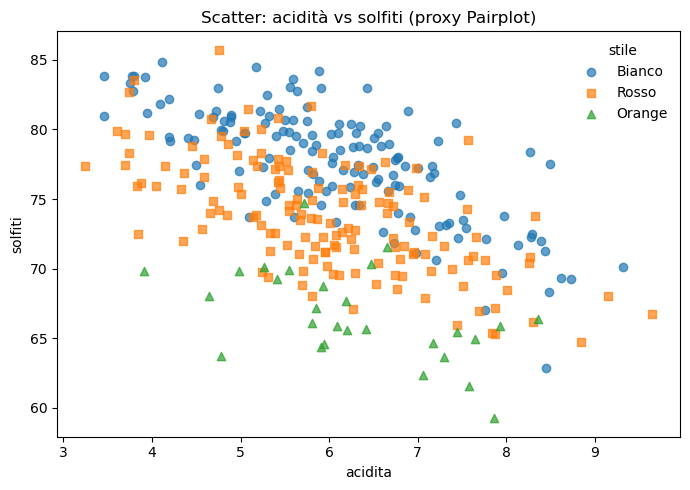

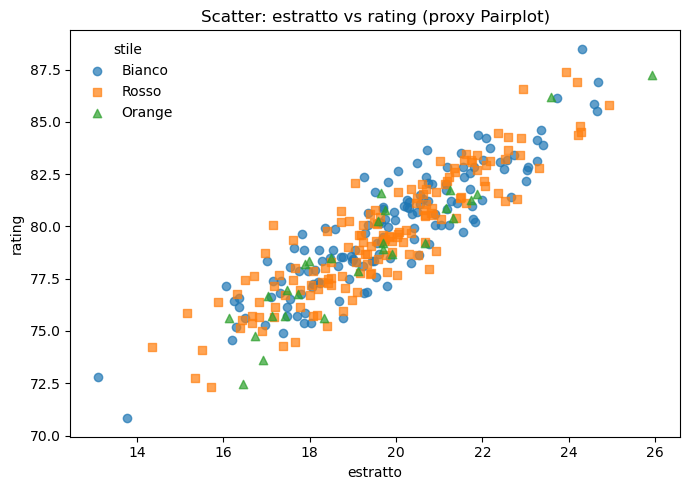

In [5]:
def scatter_by_group(x, y, group="stile", title=None):
    plt.figure(figsize=(7, 5))
    ax = plt.gca()
    markers = {"Bianco": "o", "Rosso": "s", "Orange": "^"}
    for g in ["Bianco", "Rosso", "Orange"]:
        sub = df[df[group] == g]
        ax.scatter(sub[x], sub[y], marker=markers[g], alpha=0.7, label=g)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(title or f"{x} vs {y}")
    ax.legend(frameon=False, title=group)
    plt.tight_layout()
    plt.show()

scatter_by_group("alcol", "prezzo", title="Scatter: alcol vs prezzo (proxy Pairplot)")
scatter_by_group("acidita", "solfiti", title="Scatter: acidità vs solfiti (proxy Pairplot)")
scatter_by_group("estratto", "rating", title="Scatter: estratto vs rating (proxy Pairplot)")

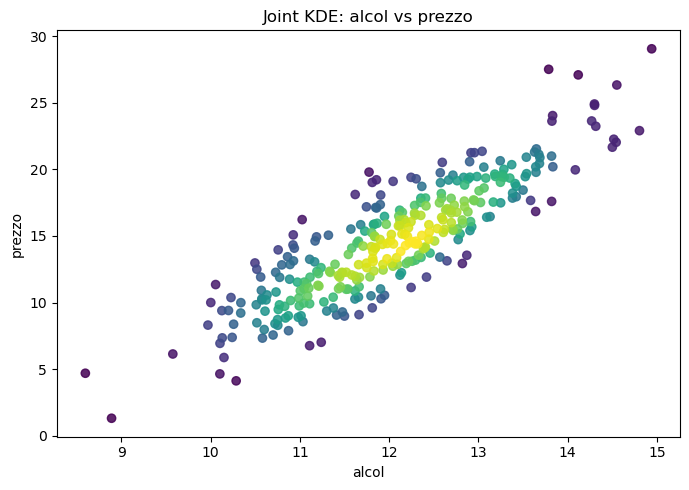

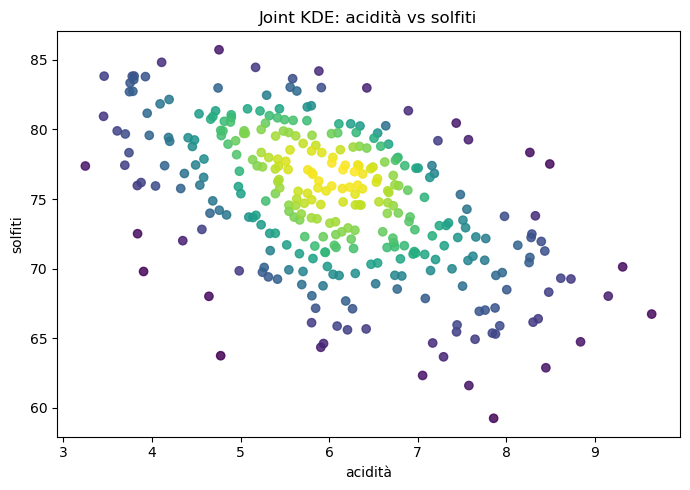

In [6]:
def kde_density_scatter(x, y, title=None):
    x = df[x].to_numpy()
    y = df[y].to_numpy()
    xy = np.vstack([x, y])
    dens = gaussian_kde(xy)(xy)

    order = np.argsort(dens)  # densità bassa sotto, alta sopra
    plt.figure(figsize=(7, 5))
    ax = plt.gca()
    ax.scatter(x[order], y[order], c=dens[order], alpha=0.85)
    ax.set_xlabel(title.split(":")[1].split("vs")[0].strip() if title else "x")
    ax.set_ylabel(title.split("vs")[1].strip() if title and "vs" in title else "y")
    ax.set_title(title or "Joint view (densità KDE)")
    plt.tight_layout()
    plt.show()

kde_density_scatter("alcol", "prezzo", title="Joint KDE: alcol vs prezzo")
kde_density_scatter("acidita", "solfiti", title="Joint KDE: acidità vs solfiti")

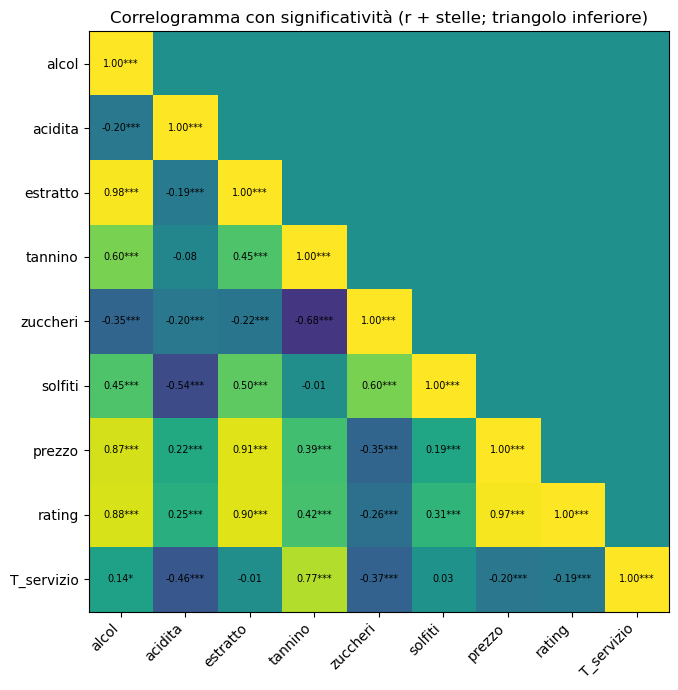

In [7]:
corr = df[numeric_cols].corr()

pvals = pd.DataFrame(np.ones_like(corr), index=corr.index, columns=corr.columns, dtype=float)
for i, c1 in enumerate(numeric_cols):
    for j, c2 in enumerate(numeric_cols):
        if i == j:
            pvals.iloc[i, j] = 0.0
        else:
            r, p = pearsonr(df[c1], df[c2])
            pvals.iloc[i, j] = p

def stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return ""

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
corr_m = corr.mask(mask)
pvals_m = pvals.mask(mask)

plt.figure(figsize=(9, 7))
ax = plt.gca()
ax.imshow(corr_m.fillna(0).values, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.index)
ax.set_title("Correlogramma con significatività (r + stelle; triangolo inferiore)")

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        if np.isnan(corr_m.iloc[i, j]):
            continue
        label = f"{corr_m.iloc[i, j]:.2f}{stars(pvals_m.iloc[i, j])}"
        ax.text(j, i, label, ha="center", va="center", fontsize=7)

plt.tight_layout()
plt.show()

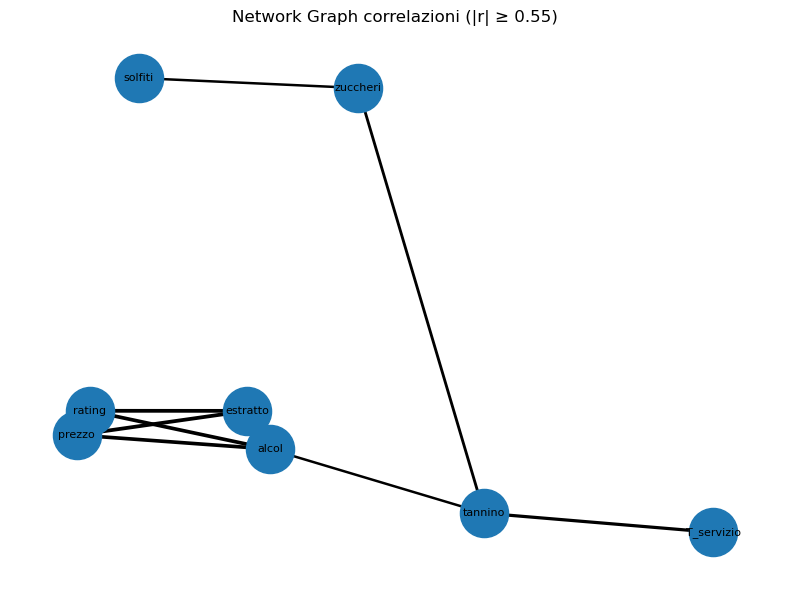

In [8]:
corr = df[numeric_cols].corr()
threshold = 0.55

G = nx.Graph()
for i, a in enumerate(numeric_cols):
    for b in numeric_cols[i+1:]:
        w = corr.loc[a, b]
        if abs(w) >= threshold:
            G.add_edge(a, b, weight=float(w))

pos = nx.spring_layout(G, seed=7)
widths = [abs(G[u][v]["weight"]) * 3 for u, v in G.edges()]

plt.figure(figsize=(8, 6))
ax = plt.gca()
nx.draw(G, pos, with_labels=True, width=widths, node_size=1200, font_size=8, ax=ax)
plt.title(f"Network Graph correlazioni (|r| ≥ {threshold})")
plt.tight_layout()
plt.show()

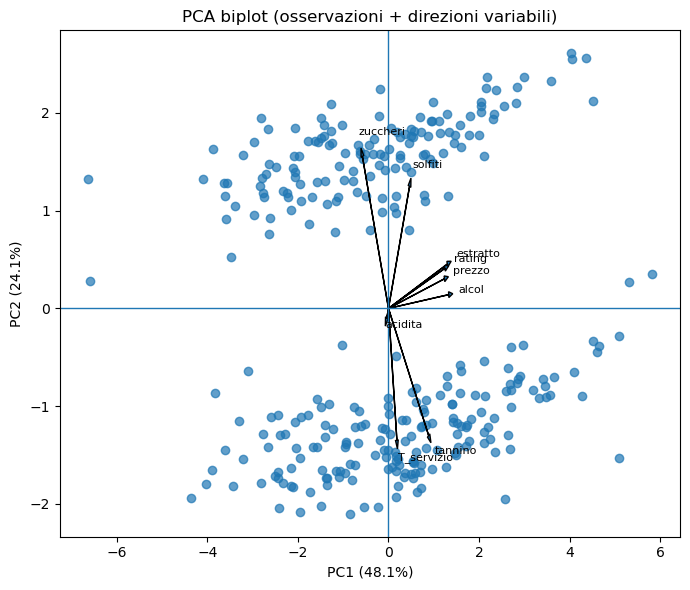

Top variabili per contributo (|loading|) su PC1:
alcol       0.473287
estratto    0.461706
rating      0.443955
prezzo      0.441181
tannino     0.312688
Name: PC1, dtype: float64

Top variabili per contributo (|loading|) su PC2:
zuccheri      0.546404
T_servizio    0.478855
tannino       0.458030
solfiti       0.444198
estratto      0.160937
Name: PC2, dtype: float64


In [9]:
X = df[numeric_cols].to_numpy()
Xz = StandardScaler().fit_transform(X)

pca = PCA(n_components=2, random_state=7)
Z = pca.fit_transform(Xz)
loadings = pca.components_.T  # (n_features, 2)

plt.figure(figsize=(7, 6))
ax = plt.gca()
ax.scatter(Z[:, 0], Z[:, 1], alpha=0.7)
ax.axhline(0, linewidth=1)
ax.axvline(0, linewidth=1)

scale = 3.0
for i, col in enumerate(numeric_cols):
    ax.arrow(0, 0, loadings[i, 0]*scale, loadings[i, 1]*scale,
             length_includes_head=True, head_width=0.06)
    ax.text(loadings[i, 0]*scale*1.08, loadings[i, 1]*scale*1.08, col, fontsize=8)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("PCA biplot (osservazioni + direzioni variabili)")
plt.tight_layout()
plt.show()

loading_df = pd.DataFrame(loadings, index=numeric_cols, columns=["PC1", "PC2"])
print("Top variabili per contributo (|loading|) su PC1:")
print(loading_df["PC1"].abs().sort_values(ascending=False).head(5))
print("\nTop variabili per contributo (|loading|) su PC2:")
print(loading_df["PC2"].abs().sort_values(ascending=False).head(5))